In [ ]:
#Q:21
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

iris = load_iris()
x = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = SVC(kernel='linear')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

#Q:22
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#load the wine dataset
wine = load_wine()
#features and target
x = wine.data
y = wine.target

#split the data into training and testing sets 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#train test the SVM model with linear kernel
linear_svm = SVC(kernel='linear')
linear_svm.fit(x_train,y_train)
#PREDICTON
y_pred_linear = linear_svm.predict(x_test)
accuracy_linear = accuracy_score(y_test,y_pred_linear)

#classifier with RBF kernel
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(x_train,y_train)
#prediction
y_pred_rbf = rbf_svm.predict(x_test)
accuracy_rbf = accuracy_score(y_test,y_pred_rbf)

#compairing their accuracies

print("Accuracy of linear SVM:",accuracy_linear)
print("Accuracy of RBF SVM :,",accuracy_rbf)

#Q:23
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()
x = housing.data
y = housing.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = SGDRegressor(max_iter=1000, tol=1e-3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("mean squared error:",mse)

#Q:24
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt

iris = load_iris()
x = iris.data[:,:2]#selecting ony two feature for visualization

x = iris.data[:,:2]#selecting ony two feature for visualization
y = iris.target.ravel()#flattening the target array
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = SVC(kernel='poly',degree=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

#visualization
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='viridis',edgecolors='k')

plt.title("SVM with polynomial kernel")
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

#Q:25
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = GaussianNB()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)




accuracy: 0.9957983193277311
accuracy for c=0.1: 0.8333333333333334


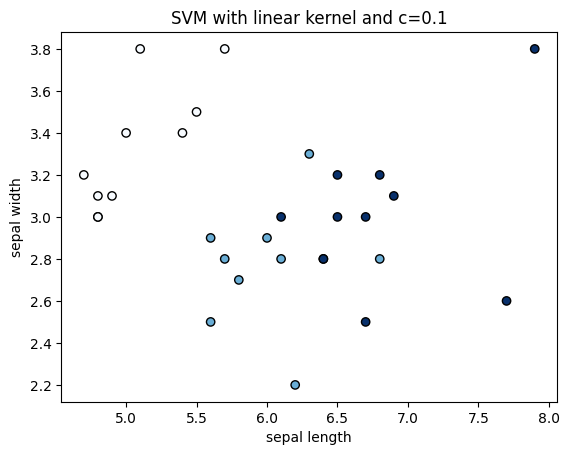

accuracy for c=1: 0.9


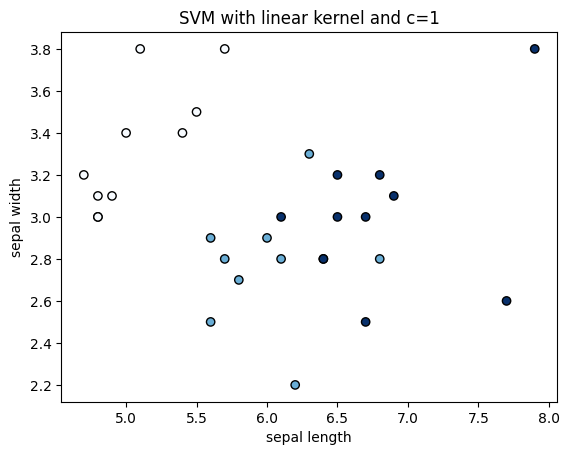

accuracy for c=10: 0.9


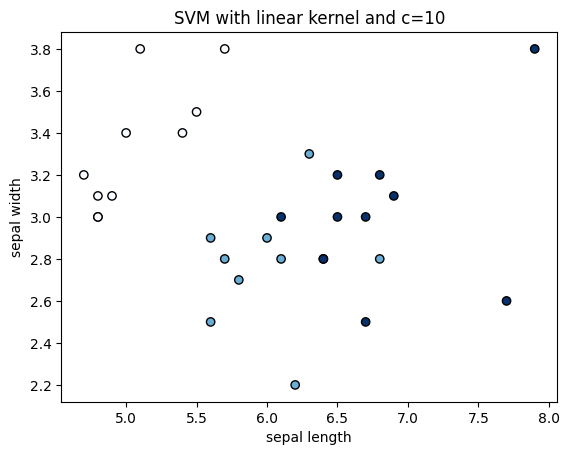

In [ ]:
#Q:26
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

#load dataset
data = fetch_20newsgroups(categories=['sci.space','rec.sport.baseball'])
x = data.data
y = data.target

#convert text labels to numerical labels
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = MultinomialNB()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

#Q:27
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt

#load dataset 
iris = load_iris()
x = iris.data[:,:2]
y = iris.target.ravel()

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#SVC with different c values and also compare their visualization
c_values = [0.1,1,10]
for i in c_values:
    model = SVC(kernel='linear',C=i)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"accuracy for c={i}:",accuracy)

#visualization
    plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='Blues',edgecolors='k')
    plt.title(f"SVM with linear kernel and c={i}")
    plt.xlabel("sepal length")
    plt.ylabel("sepal width")
    plt.show()


In [ ]:
#Q:28
#dataset with binary classification
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df.head()

#Q:29
# Demonstrate one-hot encoding for categorical data
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_df = pd.DataFrame({
    'color': ['red', 'green', 'blue', 'green', 'red'],
    'size': ['S', 'M', 'L', 'S', 'M'],
    'price': [10, 15, 20, 12, 14]
})
print("Original categorical DataFrame:")
print(cat_df)

encoder = OneHotEncoder(sparse=False, drop='first')
ct = ColumnTransformer([('onehot', encoder, ['color', 'size'])], remainder='passthrough')
encoded_array = ct.fit_transform(cat_df)
feature_names = encoder.get_feature_names_out(['color', 'size'])
encoded_df = pd.DataFrame(encoded_array, columns=list(feature_names) + ['price'])
print("\nOne-hot encoded DataFrame:")
print(encoded_df)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
